# FRBs data plotting

Notebook for visualisations of our FRB data:

- ${\rm DM}-z$ linear relation
- ${\rm DM}-z$ pdf cosmic relation
- Sky distribution

### Import packages & run parameters

In [1]:
SAVE_FIG = False

In [2]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

## Plotting
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'


## Astropy
from astropy.coordinates import Angle

## Reading FRB data

We analyse two datasets of localised FRB data:

1. Macquart+ (2020) [[here](https://arxiv.org/abs/2005.13161)] 'golden FRBs'
2. Well-localised (i.e. with redshift) FRBs (includes the Macquart data)

For these we have two dispersion measures.

- ${\rm DM}$ is the total observed dispersion measure
- ${\rm DM}_{\rm ext}$ is the extragalactic dispersion measure (correcting for MW)

- Macquart FRBs

In [8]:
frb_data_macq=pd.read_csv('../../Data/FRB_Macquart.csv')
frb_data_macq

,FRB,z,DM,DM_ext,gl,gb,From
0,FRB 20180924B,0.3214,361.42,290.92,0.7424,-49.4147,Surajit
1,FRB 20181112A,0.4755,589.27,457.27,342.5995,-47.6988,Surajit
2,FRB 20190102C,0.2910,363.60,276.30,312.6537,-33.4931,Surajit
3,FRB 20190608B,0.1178,338.70,271.50,53.2088,-48.5296,Surajit
4,FRB 20190711A,0.5220,593.10,506.70,310.9081,-33.9020,Surajit


- All (localised) FRBs

In [3]:
frb_data_all=pd.read_csv('../../Data/FRB.csv')
frb_data_all

,FRB,z,DM,DM_ext,gl,gb,From,Ref
0,FRB 20180814A,0.06800,190.900,73.30,136.460000,16.580000,Fan,https://www.nature.com/articles/s41586-018-0864-x
1,FRB 20181030A,0.00385,103.396,32.30,133.400000,40.900000,Fan,https://iopscience.iop.org/article/10.3847/204...
2,FRB 20220529A,0.18390,246.000,176.00,130.787670,-41.858020,Fan,https://arxiv.org/abs/2503.04727
3,FRB 20220610A,1.01600,1458.150,1397.15,8.839200,-70.185700,Fan,https://www.cambridge.org/core/journals/public...
4,FRB 20220717A,0.36295,637.340,489.04,19.835158,-17.632032,Fan,https://arxiv.org/pdf/2407.02173
...,...,...,...,...,...,...,...,...
112,FRB 20231204A,0.06440,221.000,159.94,97.623756,65.928145,CHIME2025,https://arxiv.org/pdf/2502.11217
113,FRB 20231206A,0.06590,457.700,370.12,161.058167,27.481895,CHIME2025,https://arxiv.org/pdf/2502.11217
114,FRB 20231223C,0.10590,165.800,87.07,52.310724,32.080162,CHIME2025,https://arxiv.org/pdf/2502.11217
115,FRB 20231229A,0.01900,198.500,110.98,135.344911,-26.443349,CHIME2025,https://arxiv.org/pdf/2502.11217


**Do we have duplicates?**

In [4]:
(frb_data_all['z'].values).size, np.unique(frb_data_all['z'].values).size, np.unique(frb_data_all['DM_ext'].values).size

(117, 114, 117)

In [5]:
duplicates = []

for idx_1, frb_1 in enumerate(frb_data_all['FRB']):
    for idx_2, frb_2 in enumerate(frb_data_all['FRB']):
        if ((frb_data_all['z'][idx_1] == frb_data_all['z'][idx_2]) or (frb_data_all['DM_ext'][idx_1] == frb_data_all['DM_ext'][idx_2])) and (idx_1 != idx_2):
            duplicates.append(idx_1)

In [6]:
for idx in duplicates:
    print(f"FRB name: {frb_data_all['FRB'][idx]} has z={frb_data_all['z'][idx]} and DM_ext={frb_data_all['DM_ext'][idx]}, and DM_obs={frb_data_all['DM'][idx]}.")

FRB name: FRB 20230814A has z=0.553 and DM_ext=561.6, and DM_obs=696.4.
FRB name: FRB 20220726A has z=0.3619 and DM_ext=571.37, and DM_obs=686.55.
FRB name: FRB 20221219A has z=0.553 and DM_ext=632.3, and DM_obs=706.708.
FRB name: FRB 20230628A has z=0.127 and DM_ext=276.35, and DM_obs=344.952.
FRB name: FRB 20230902A has z=0.3619 and DM_ext=376.1, and DM_obs=440.1.
FRB name: FRB 20240310A has z=0.127 and DM_ext=535.8, and DM_obs=601.8.


**Note**: All FRBs are different, but some of them share the same redshift

**FRB cuts**

We perform two cuts in the FRBs analysis:

- Remove two FRBs that have very large DMs for their redshift.
- We perform a redshift cut (for small redshifts), since these are creating an issue with the variance calculation (see paper & other notebooks for details)

In [12]:
z_cut=0.2

## Cutting the data
frb_data_cut = frb_data_all[frb_data_all['FRB'] != 'FRB 20190520B']
frb_data_cut = frb_data_all[frb_data_all['FRB'] != 'FRB 20220831A']
frb_data_cut = frb_data_all[frb_data_all['z'] >= z_cut]

print(f"Original data had {len(frb_data_all)}, while the cut data have {len(frb_data_cut)} FRBs.")

Original data had 117, while the cut data have 58 FRBs.


**DM-z overview plot**

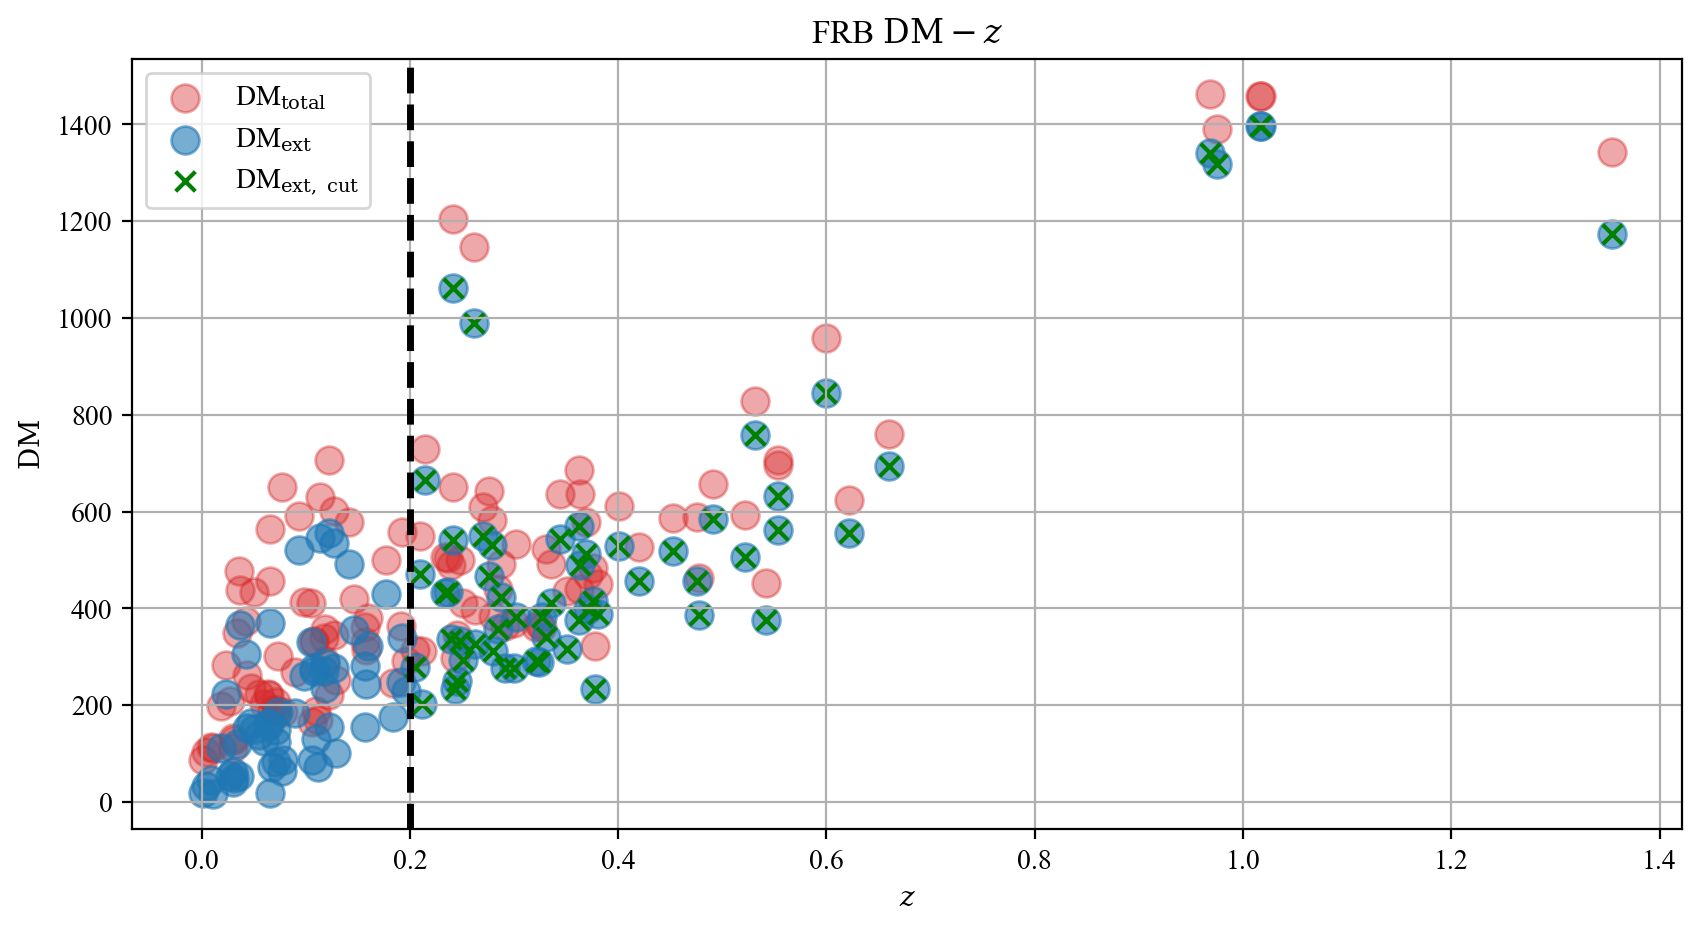

In [13]:
fig = plt.figure(figsize=(10, 5), dpi=200)
ax1 = fig.add_subplot(111)

ax1.scatter(frb_data_all['z'], frb_data_all['DM'], s=100, marker='o', label=r'DM$_{\rm total}$', alpha=0.4, c='tab:red')
ax1.scatter(frb_data_all['z'], frb_data_all['DM_ext'], s=100, marker='o', label=r'DM$_{\rm ext}$', alpha=0.6)
ax1.scatter(frb_data_cut['z'], frb_data_cut['DM_ext'], s=50, marker='x', label=r'DM$_{\rm ext,\ cut}$', c='green')

ax1.axvline(x=z_cut, ls='--', lw=2.5, c='black')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'${\rm DM}$')
ax1.set_title(r'FRB ${\rm DM}-z$')
ax1.grid(True)
ax1.legend(loc='upper left')


if SAVE_FIG:
    plt.savefig("frb_all_cut_DM_z.png", dpi=200)

plt.show()
plt.close()

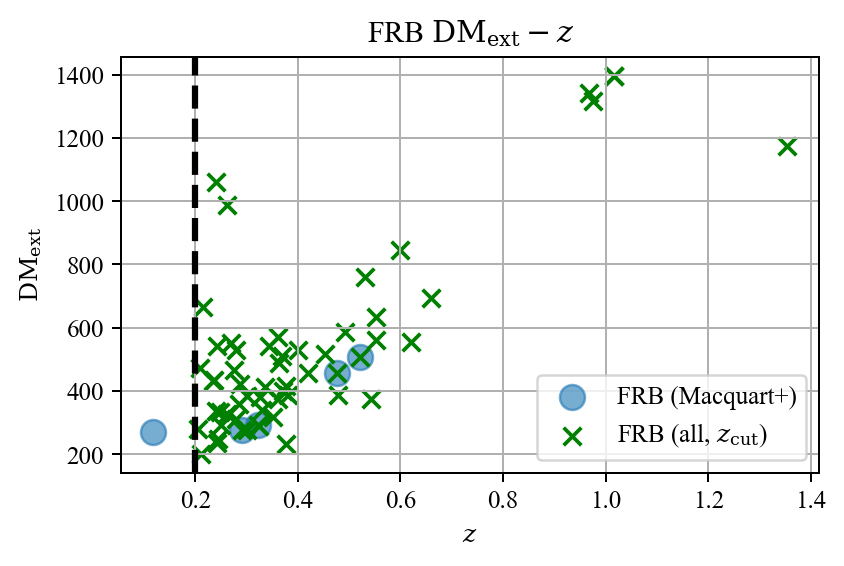

In [28]:
fig = plt.figure(figsize=(5, 3), dpi=180)
ax1 = fig.add_subplot(111)

ax1.scatter(frb_data_macq['z'], frb_data_macq['DM_ext'], s=100, marker='o', label=r'FRB (Macquart+)', alpha=0.6)
ax1.scatter(frb_data_cut['z'], frb_data_cut['DM_ext'], s=50, marker='x', label=r'FRB (all, $z_{\rm cut}$)', c='green')

ax1.axvline(x=z_cut, ls='--', lw=2.5, c='black')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'${\rm DM_{\rm ext}}$')
ax1.set_title(r'FRB ${\rm DM_{\rm ext}}-z$')
ax1.grid(True)
ax1.legend(loc='lower right')

if SAVE_FIG:
    plt.savefig("frb_all_cut_Macq_DM_z.png", dpi=180)
    
plt.show()
plt.close()

## Linear fits with the FRB data

We investigate 3 cases, where in all we fit a least-squares linear relation ($y = a+b x$):

- Fit all FRBs
- Fit FRBs at lower redshifts (z<0.8)
- Fit FRBs after the cut
- Fit FRBs after the cut (at lower redshifts)

Finally, we plot the theoretical ${\rm DM}_{\rm IGM}$ for the relevant redshifts. Note that the theoretical IGM contribution relation, is **not** including any host effects, that's why it is smaller than most DM values.

In [29]:
slope_all, intercept_all = np.polyfit(frb_data_all['z'], frb_data_all['DM_ext'], 1)
slope_cut, intercept_cut = np.polyfit(frb_data_cut['z'], frb_data_cut['DM_ext'], 1)

z_upper_cut = 0.8

bool_z = frb_data_all['z'] < z_upper_cut
slope_lowz, intercept_lowz = np.polyfit(frb_data_all['z'][bool_z], frb_data_all['DM_ext'][bool_z], 1)

bool_z_cut = frb_data_cut['z'] < z_upper_cut
slope_lowz_cut, intercept_lowz_cut = np.polyfit(frb_data_cut['z'][bool_z_cut], frb_data_cut['DM_ext'][bool_z_cut], 1)

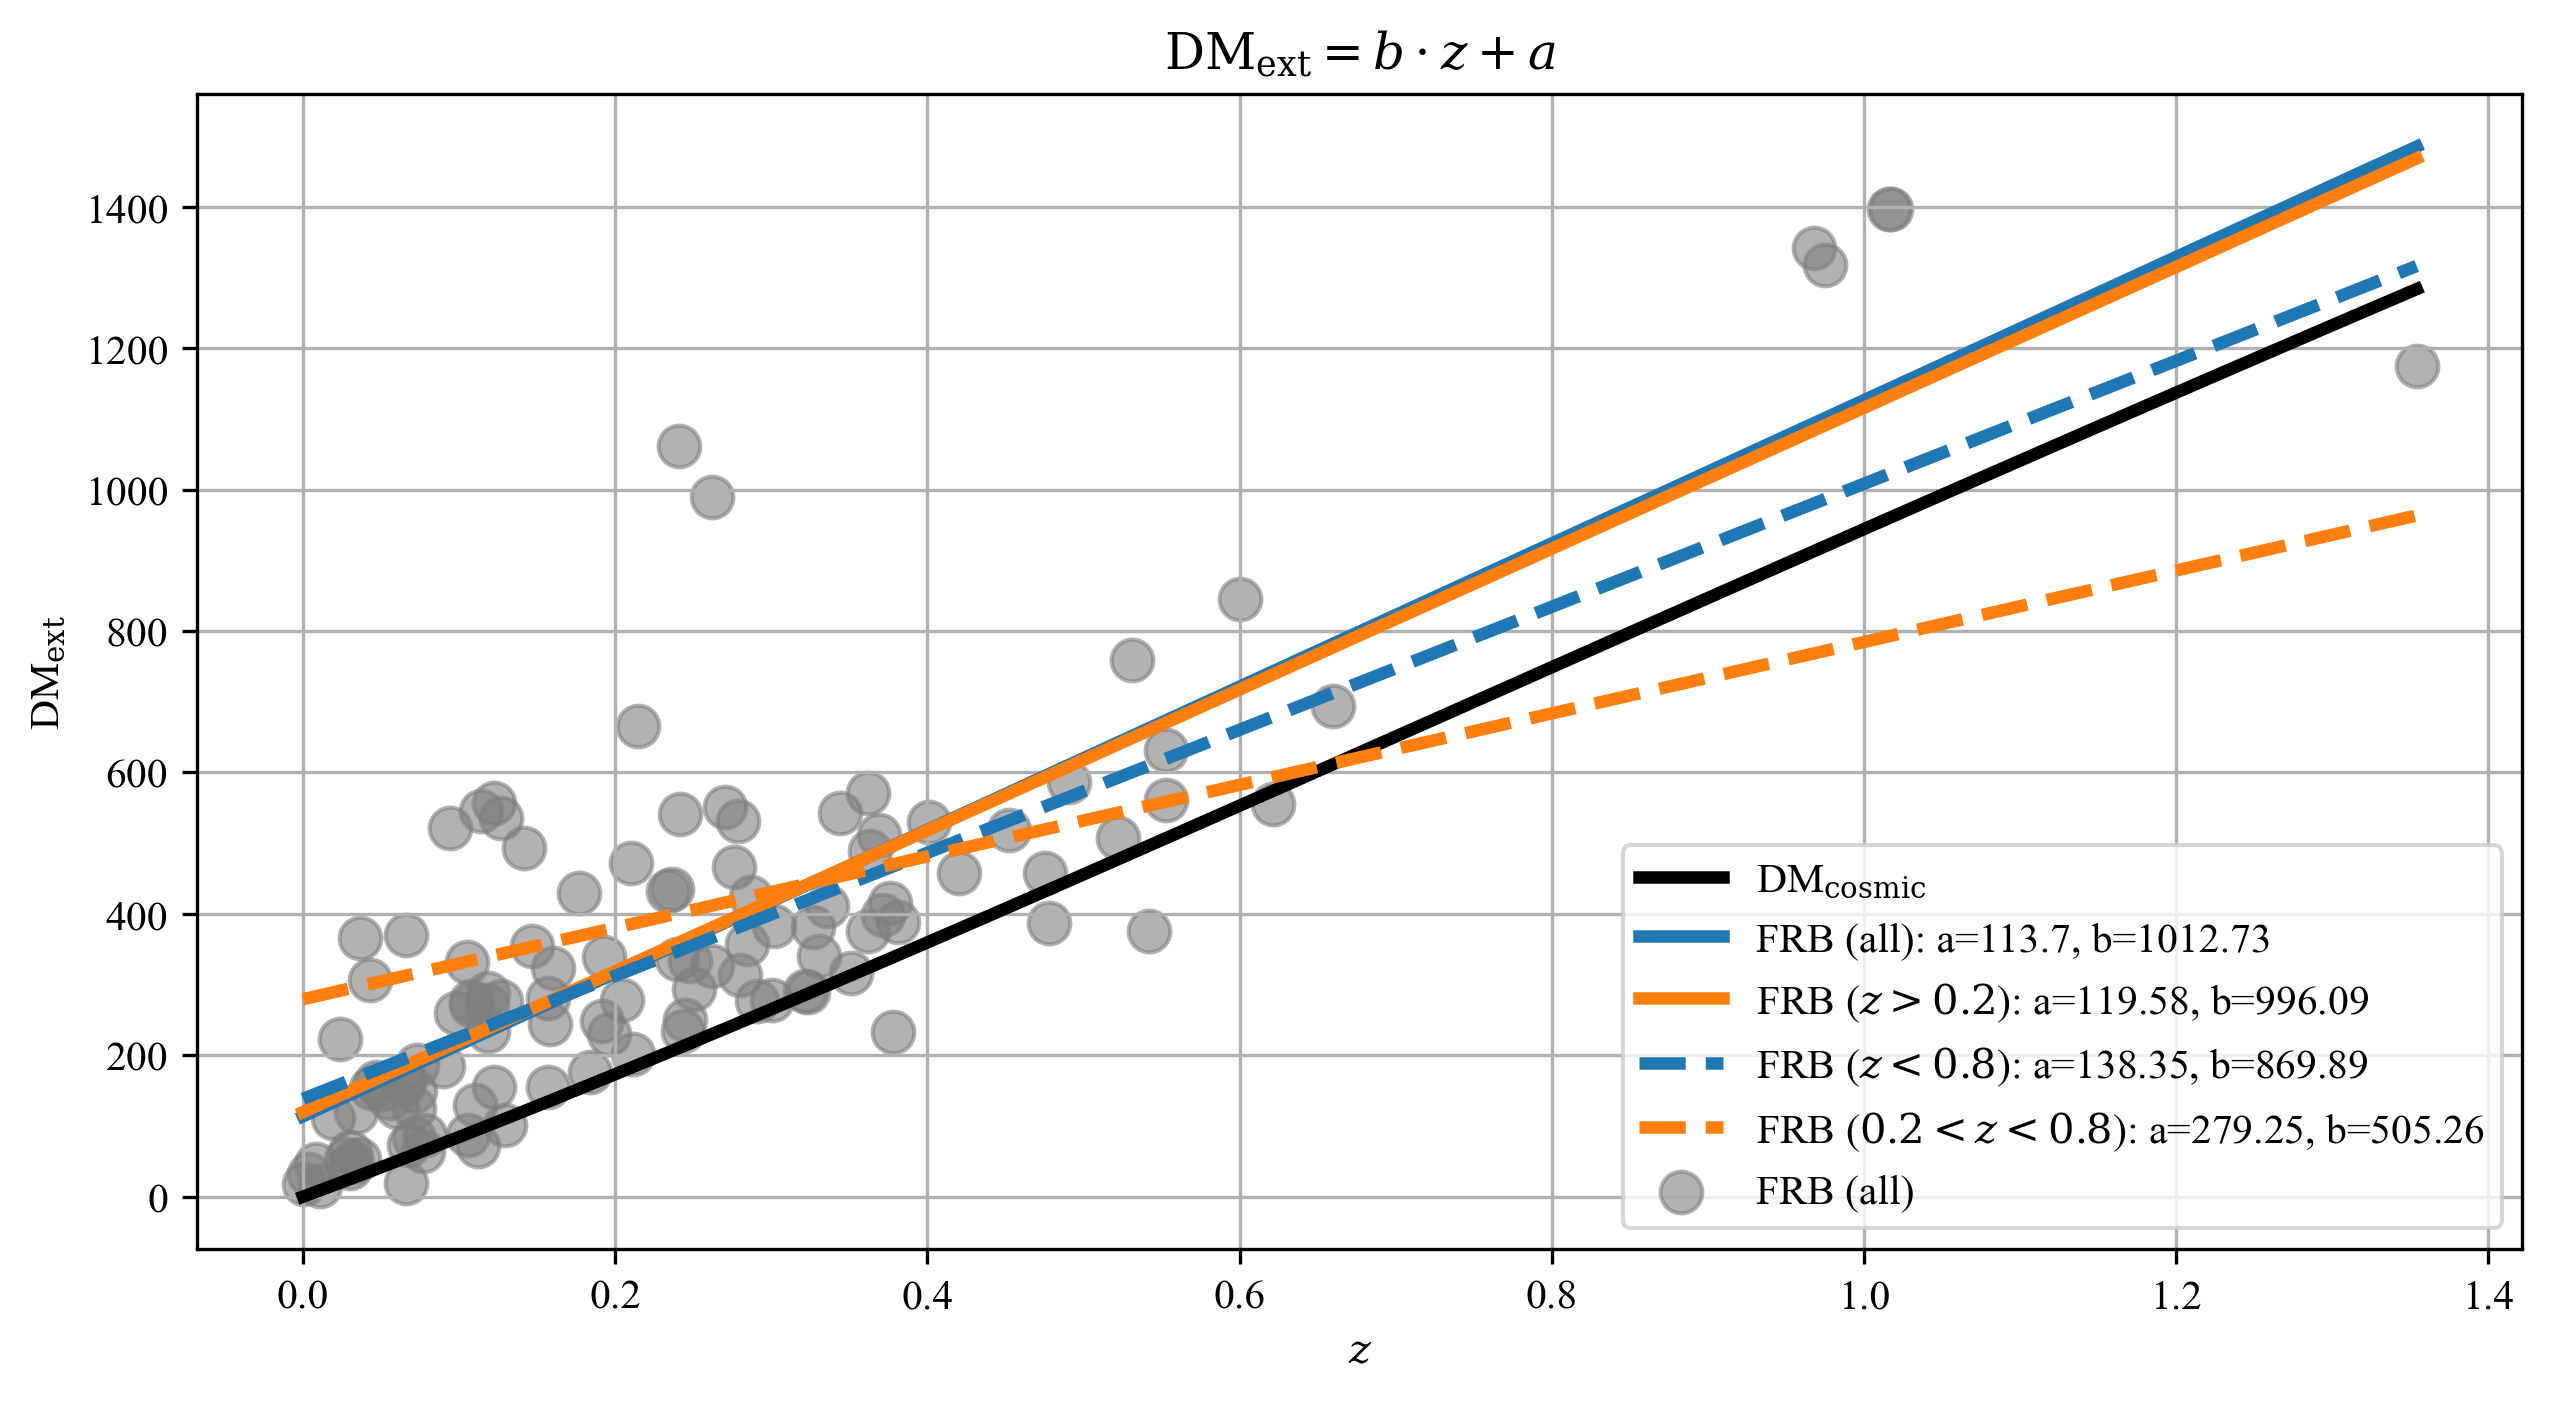

In [45]:
fig = plt.figure(figsize=(10, 5), dpi=300)
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(frb_data_all['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, DM_theory, lw=3, c='black', label=r'DM$_{\rm cosmic}$')

ax1.plot(z_range, intercept_all+slope_all*z_range, lw=3, c='tab:blue', ls='-',\
         label=f'FRB (all): a={round(intercept_all,2)}, b={round(slope_all,2)}')

ax1.plot(z_range, intercept_cut+slope_cut*z_range, lw=3, c='tab:orange', ls='-',\
         label=fr'FRB ($z>0.2$): a={round(intercept_cut,2)}, b={round(slope_cut,2)}')

ax1.plot(z_range, intercept_lowz+slope_lowz*z_range, lw=3, c='tab:blue', ls='--',\
         label=fr'FRB ($z<0.8$): a={round(intercept_lowz,2)}, b={round(slope_lowz,2)}')

ax1.plot(z_range, intercept_lowz_cut+slope_lowz_cut*z_range, lw=3, c='tab:orange', ls='--',\
         label=fr'FRB ($0.2<z<0.8$): a={round(intercept_lowz_cut,2)}, b={round(slope_lowz_cut,2)}')


ax1.scatter(frb_data_all['z'], frb_data_all['DM_ext'], s=100, marker='o', label=r'FRB (all)', alpha=0.6, c='tab:grey')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'DM$_{\rm ext}$')
ax1.set_title(r'${\rm DM_{\rm ext}}=b\cdot z+a$')
ax1.grid(True)
ax1.legend()

if SAVE_FIG:
    plt.savefig("frb_linear_fits.png", dpi=200)

plt.show()
plt.close()

**Note**: Linear relations including the high-z data are very similar in slope with the $p_{\rm cosmic}$ pdf.

---------------------------------------------------------------

## ${\rm DM}_{\rm cosmic}-z$ fits with the FRB data

<div class="alert alert-block alert-info">
  <strong>MK:</strong> Will need to update this with the updated formalism.
</div>

1. Macquart data

In [49]:
load_arrays=np.load('./interpolation/A_C0_Macquart.npz')
Sigmas=load_arrays['a']
C0s=load_arrays['c']
As=load_arrays['b']

In [51]:
## For the plot they have choses F=0.2
sigmas_golden = f_sigma_DM(F=0.2, z=frb_data_macq['z'])

## Calulate first the normalisation factors for all the 'golden' FRBs
C0_array = np.zeros_like(sigmas_golden)
A_array = np.zeros_like(sigmas_golden)
DM_theory = np.zeros_like(sigmas_golden)

for idx, z in enumerate(frb_data_macq['z']):
    C0_array[idx] = find_C0(F=0.2, z=z)
    A_array[idx] = find_A(C_0=C0_array[idx], F=0.2, z=z)
    
    ## Note that we need to use f_IGM=0.9 to be closer to their plot
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = 0.9)

In [52]:
## The range of DM_cosmic (the y-axis)
DM_cosmic_range = np.linspace(0.01, 1000, 1000)

## Calculating the theoretical solid curve
z_range = np.linspace(0.1, np.max(frb_data_macq['z']), 100)

DM_theory_range = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory_range[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = 0.9)

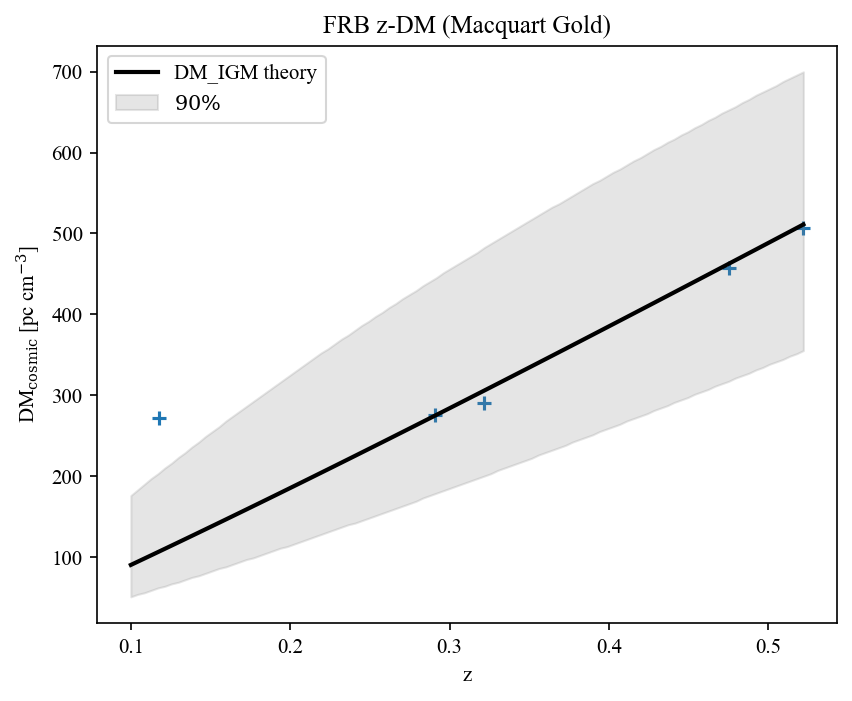

In [54]:
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)

fig = plt.figure(figsize=(14, 5), dpi=150)
ax1 = fig.add_subplot(121)

for idx, z in enumerate(frb_data_macq['z']):
    p=pdf_DM_cosmo(DM_cosmic_range/DM_theory[idx], C_0=C0_array[idx], A=A_array[idx], sigma=sigmas_golden[idx])

    ## This is nice, if we want to plot the distributions of p_cosmic on the y-axis
    # ax1.plot(z+p/np.max(p)*0.1, DM_cosmic_range, c='grey')

    
for idx, z in enumerate(z_range):
    sigma = f_sigma_DM(F=0.2, z=z)
    C0 = find_C0(F=0.2, z=z)
    A = find_A(C_0=C0, F=0.2, z=z)
    DM_th = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = 0.9)
    p=pdf_DM_cosmo(DM_cosmic_range/DM_th, C_0=C0, A=A, sigma=sigma)
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    cdf = np.cumsum(normalise(p))
    y_high[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.95))]
    y_low[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.05))]

    
ax1.scatter(frb_data_macq['z'], frb_data_macq['DM_ext'], s=50, marker='+')  
ax1.plot(z_range, DM_theory_range, lw=2, c='black', label='DM_IGM theory')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=r'$90\%$')
ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm cosmic}$ [pc cm$^{-3}$]')
ax1.set_title('FRB z-DM (Macquart Gold)')
ax1.legend(loc='upper left')

if SAVE_FIG:
    plt.savefig("DMcosmic_Macq.png", dpi=200)

plt.show()
plt.close()

----------------------------------------------------------------------

## FRB sky maps

We project the FRB positions on the sky, using two coordinate systems for the Mollweide projection:

1. Equatorial coordinates (IRCS)
2. Galactic coordinates

- **Equatorial coordinates**

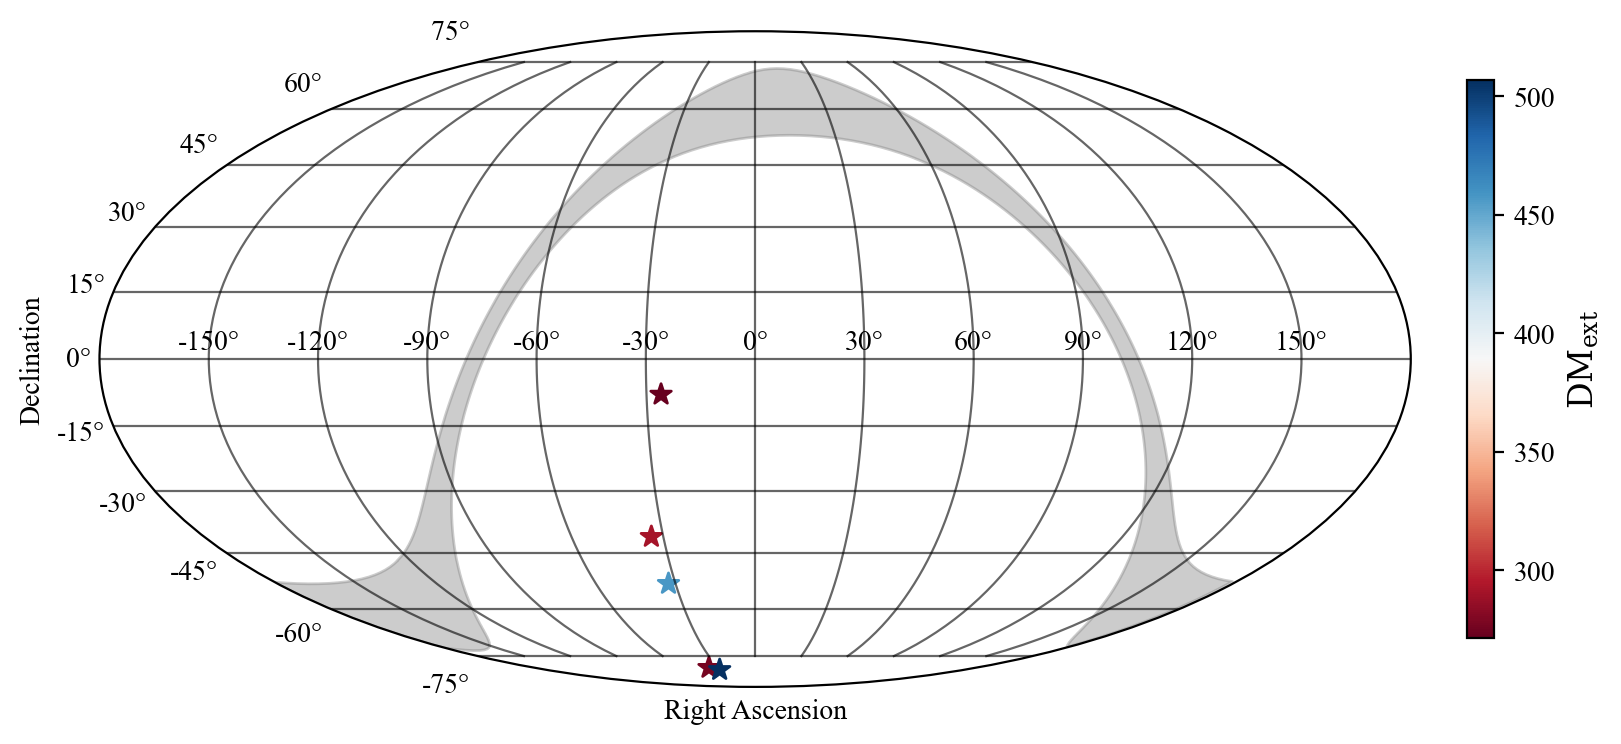

In [9]:
b_max = 10  # ZoA from -10° to +10° in galactic latitude

l_vals = np.linspace(-63, 296, 200)  # degrees

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# Convert to ICRS coordinates
gal_plane = SkyCoord(l=l_vals*u.deg, b=0*u.deg, frame='galactic')
gal_upper = SkyCoord(l=l_vals*u.deg, b=b_upper*u.deg, frame='galactic')
gal_lower = SkyCoord(l=l_vals*u.deg, b=b_lower*u.deg, frame='galactic')
gal_macq  = SkyCoord(l=frb_data_macq['gl']*u.deg, b=frb_data_macq['gb']*u.deg, frame='galactic')

icrs_plane = gal_plane.icrs
icrs_upper = gal_upper.icrs
icrs_lower = gal_lower.icrs
icrs_macq  = gal_macq.icrs

# Convert RA to [-180°, +180°] for Mollweide projection
ra_plane = icrs_plane.ra.wrap_at(180 * u.deg).radian
dec_upper = icrs_upper.dec.radian
dec_lower = icrs_lower.dec.radian

ra_macq = icrs_macq.ra.wrap_at(180 * u.deg).radian
dec_mac = icrs_macq.dec.radian

# Plot
fig = plt.figure(figsize=(9, 5), dpi=200)
ax = fig.add_subplot(111, projection='mollweide')

ax.fill_between(ra_plane, dec_lower, dec_upper, color='gray', alpha=0.4)
map1 = ax.scatter(ra_macq, dec_mac, marker='*', s=60, c=frb_data_macq['DM_ext'], cmap='RdBu')

ax.grid(True, c='black', alpha=0.6)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")

cbar = fig.colorbar(map1, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label(r'${\rm DM}_{\rm ext}$', fontsize=12)

if SAVE_FIG:
    plt.savefig("sky_macq_icrs.png", dpi=200)

plt.show()
plt.close()

2. All data

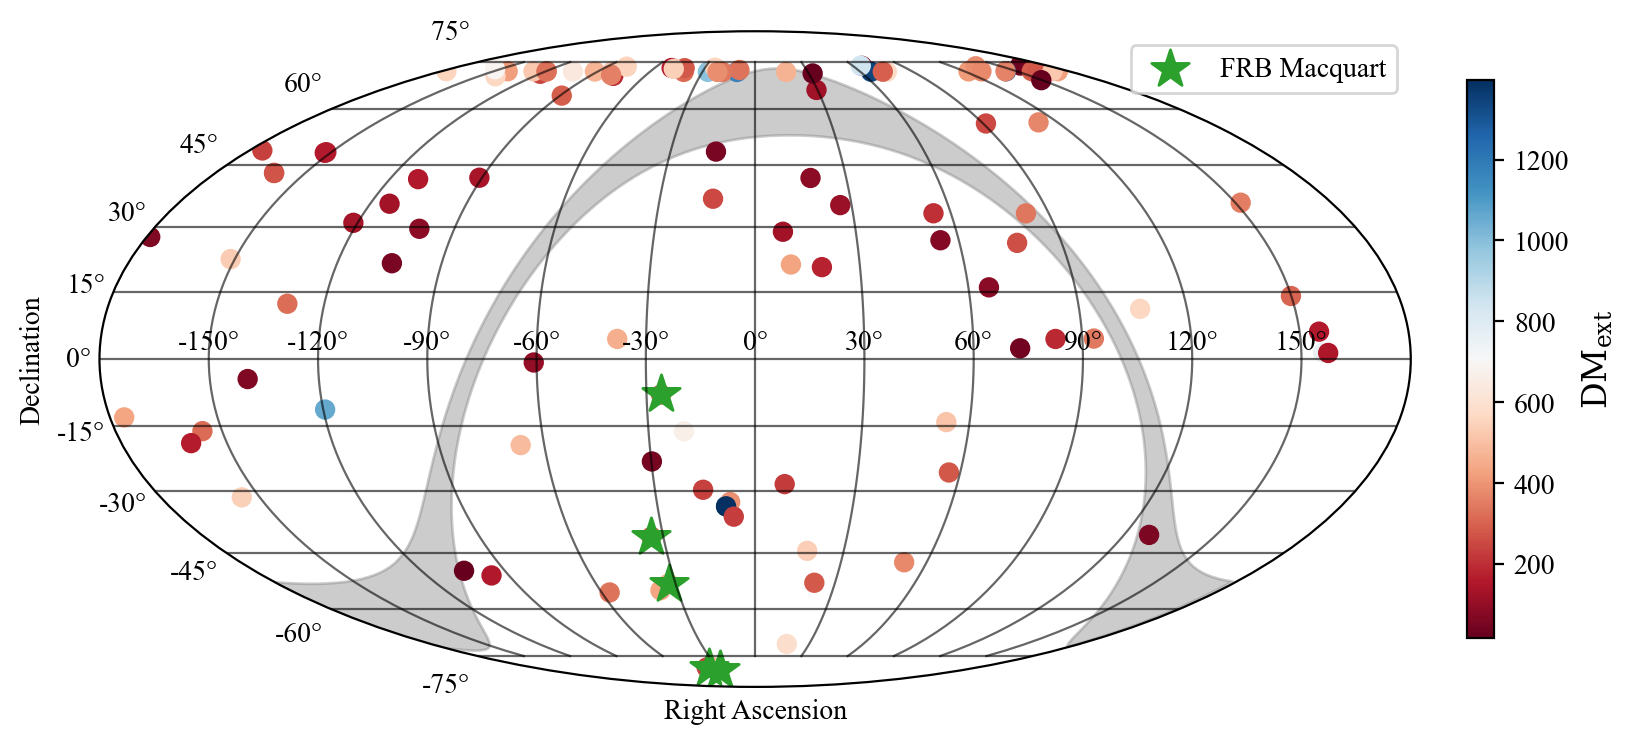

In [10]:
b_max = 10  # ZoA from -10° to +10° in galactic latitude

l_vals = np.linspace(-63, 296, 200)  # degrees

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# Convert to ICRS coordinates
gal_plane = SkyCoord(l=l_vals*u.deg, b=0*u.deg, frame='galactic')
gal_upper = SkyCoord(l=l_vals*u.deg, b=b_upper*u.deg, frame='galactic')
gal_lower = SkyCoord(l=l_vals*u.deg, b=b_lower*u.deg, frame='galactic')
gal_macq  = SkyCoord(l=frb_data_macq['gl']*u.deg, b=frb_data_macq['gb']*u.deg, frame='galactic')
gal_all   = SkyCoord(l=frb_data_all['gl']*u.deg, b=frb_data_all['gb']*u.deg, frame='galactic')

icrs_plane = gal_plane.icrs
icrs_upper = gal_upper.icrs
icrs_lower = gal_lower.icrs
icrs_macq  = gal_macq.icrs
icrs_all   = gal_all.icrs

# Convert RA to [-180°, +180°] for Mollweide projection
ra_plane = icrs_plane.ra.wrap_at(180 * u.deg).radian
dec_upper = icrs_upper.dec.radian
dec_lower = icrs_lower.dec.radian

ra_macq = icrs_macq.ra.wrap_at(180 * u.deg).radian
dec_mac = icrs_macq.dec.radian

ra_all  = icrs_all.ra.wrap_at(180 * u.deg).radian
dec_all = icrs_all.dec.radian

# Plot
fig = plt.figure(figsize=(9, 5), dpi=200)
ax = fig.add_subplot(111, projection='mollweide')

ax.fill_between(ra_plane, dec_lower, dec_upper, color='gray', alpha=0.4)
map2 = ax.scatter(ra_all, dec_all, marker='o', s=40, c=frb_data_all['DM_ext'], cmap='RdBu')
ax.scatter(ra_macq, dec_mac, marker='*', s=200, c='tab:green', label='FRB Macquart')



ax.grid(True, c='black', alpha=0.6)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.legend()

cbar = fig.colorbar(map2, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label(r'${\rm DM}_{\rm ext}$', fontsize=12)

if SAVE_FIG:
    plt.savefig("sky_all_icrs.png", dpi=200)

plt.show()
plt.close()

3. Redshift cut data

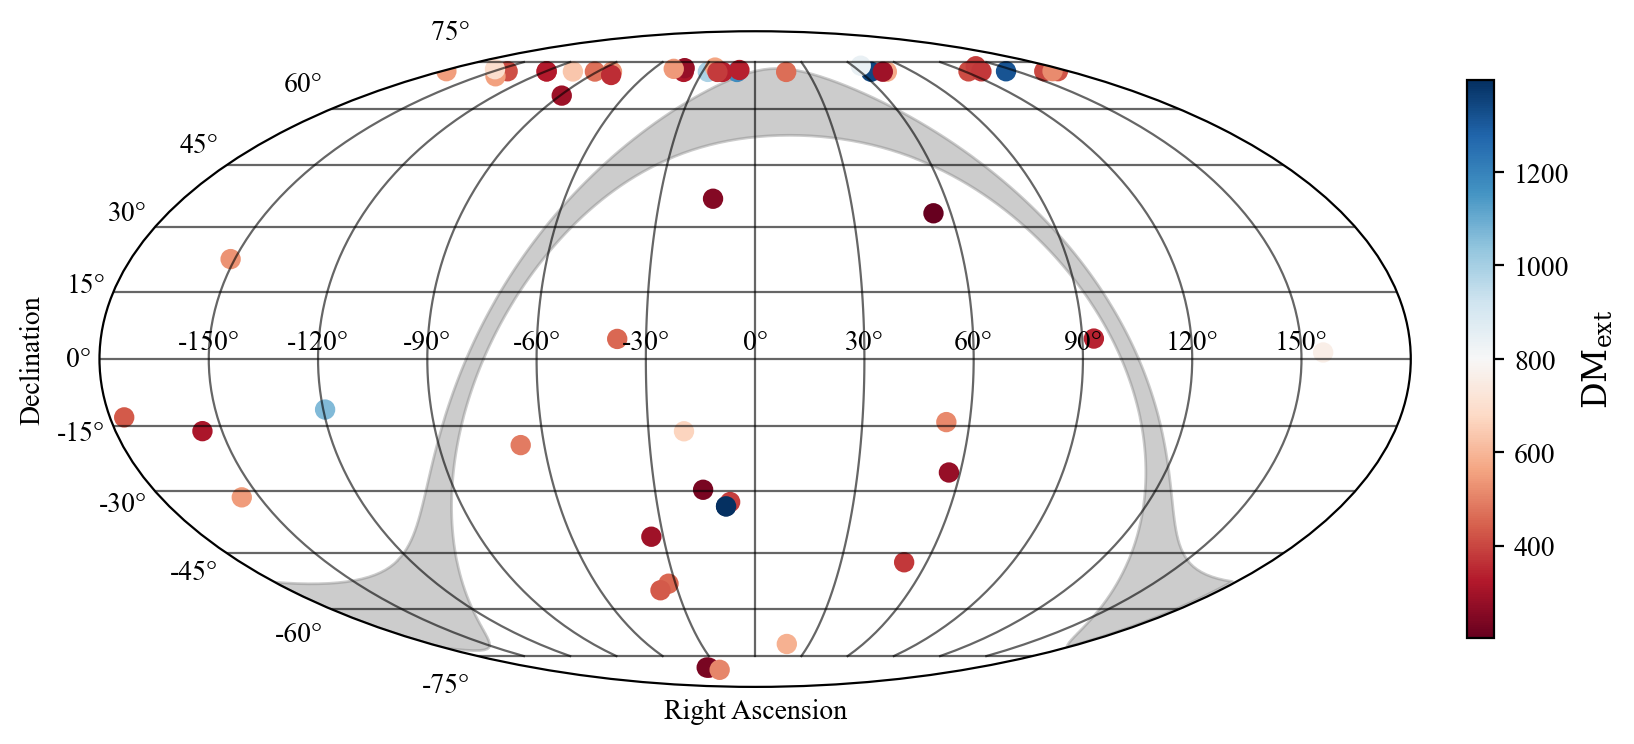

In [13]:
b_max = 10  # ZoA from -10° to +10° in galactic latitude

l_vals = np.linspace(-63, 296, 200)  # degrees

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# Convert to ICRS coordinates
gal_plane = SkyCoord(l=l_vals*u.deg, b=0*u.deg, frame='galactic')
gal_upper = SkyCoord(l=l_vals*u.deg, b=b_upper*u.deg, frame='galactic')
gal_lower = SkyCoord(l=l_vals*u.deg, b=b_lower*u.deg, frame='galactic')
gal_macq  = SkyCoord(l=frb_data_macq['gl']*u.deg, b=frb_data_macq['gb']*u.deg, frame='galactic')
gal_cut   = SkyCoord(l=frb_data_cut['gl']*u.deg, b=frb_data_cut['gb']*u.deg, frame='galactic')

icrs_plane = gal_plane.icrs
icrs_upper = gal_upper.icrs
icrs_lower = gal_lower.icrs
icrs_macq  = gal_macq.icrs
icrs_cut   = gal_cut.icrs

# Convert RA to [-180°, +180°] for Mollweide projection
ra_plane = icrs_plane.ra.wrap_at(180 * u.deg).radian
dec_upper = icrs_upper.dec.radian
dec_lower = icrs_lower.dec.radian

ra_macq = icrs_macq.ra.wrap_at(180 * u.deg).radian
dec_mac = icrs_macq.dec.radian

ra_cut  = icrs_cut.ra.wrap_at(180 * u.deg).radian
dec_cut = icrs_cut.dec.radian

# Plot
fig = plt.figure(figsize=(9, 5), dpi=200)
ax = fig.add_subplot(111, projection='mollweide')

ax.fill_between(ra_plane, dec_lower, dec_upper, color='gray', alpha=0.4)
map2 = ax.scatter(ra_cut, dec_cut, marker='o', s=40, c=frb_data_cut['DM_ext'], cmap='RdBu')
# ax.scatter(ra_macq, dec_mac, marker='*', s=200, c='tab:green', label='FRB Macquart')


ax.grid(True, c='black', alpha=0.6)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
# ax.legend()

cbar = fig.colorbar(map2, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label(r'${\rm DM}_{\rm ext}$', fontsize=12)

if SAVE_FIG:
    plt.savefig("sky_cut_icrs.png", dpi=200)

plt.show()
plt.close()

- **Galactic coordinates**

1. Macquart data

In [14]:
gl_macq = Angle(np.array(frb_data_macq['gl'])*u.deg).wrap_at(180 * u.deg).degree
gb_macq = np.array(frb_data_macq['gb'])

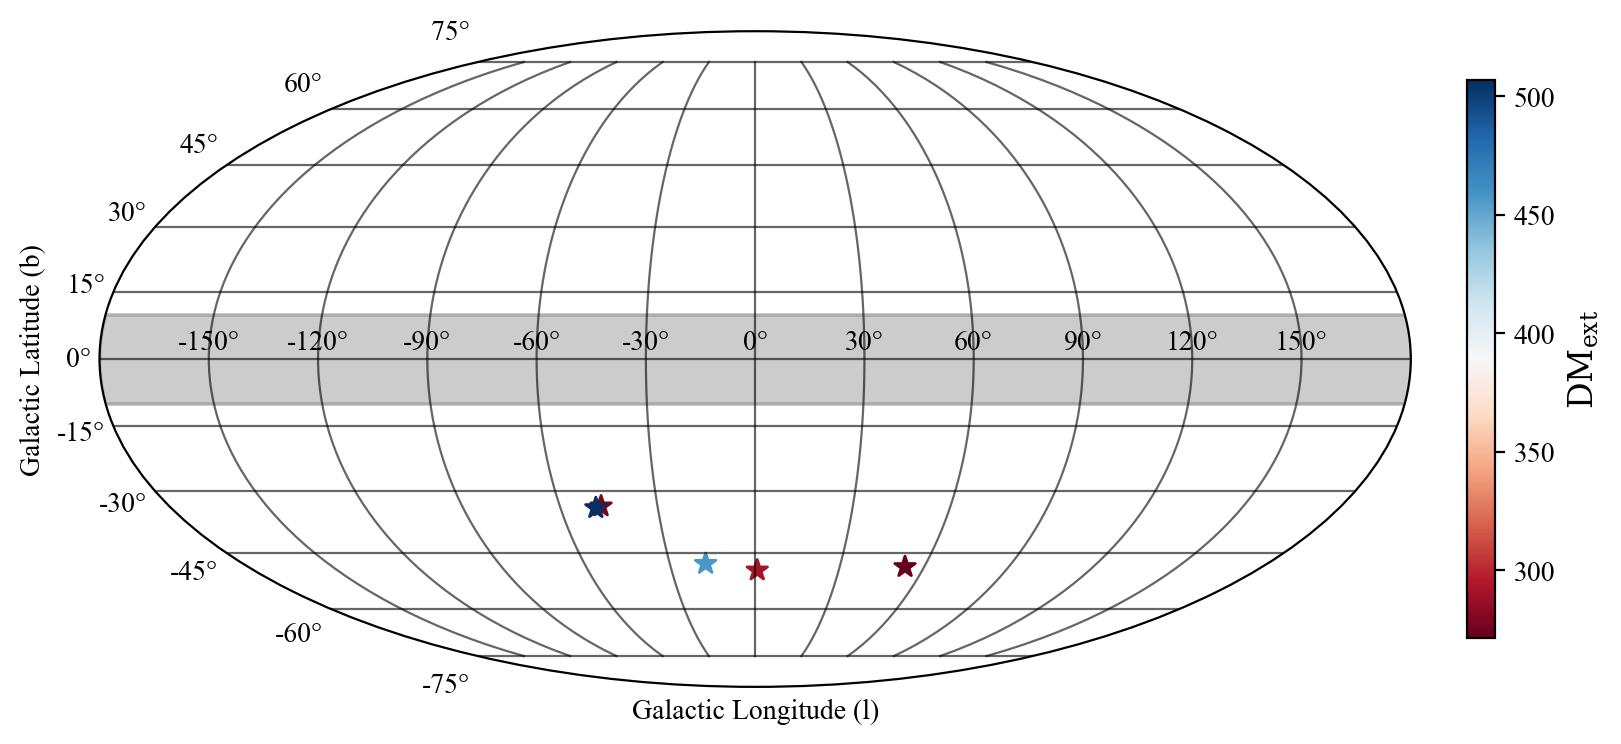

In [15]:
# Width of the Zone of Avoidance in degrees
b_max = 10  # ZoA from -10° to +10° in galactic latitude

# Galactic longitude from -180° to +180°
l_vals = np.linspace(-180, 180, 10)

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# # Concatenate to form a closed polygon (upper edge, reversed lower edge)
# l_full = np.concatenate([l_vals, l_vals[::-1]])
# b_full = np.concatenate([b_upper, b_lower[::-1]])

# Convert to radians
l_rad = np.deg2rad(l_vals)
b_rad_upper = np.deg2rad(b_upper)
b_rad_lower = np.deg2rad(b_lower)
gl_macq_rad = np.deg2rad(gl_macq)
gb_macq_rad = np.deg2rad(gb_macq)

# Plot in Mollweide projection
fig = plt.figure(figsize=(9, 5), dpi=200)
ax = fig.add_subplot(111, projection='mollweide')

# Fill the zone
ax.fill_between(l_rad, b_rad_lower, b_rad_upper, color='gray', alpha=0.4)
map1 = ax.scatter(gl_macq_rad, gb_macq_rad, marker='*', s=60, c=frb_data_macq['DM_ext'], cmap='RdBu')

# Format the plot
ax.grid(True, c='black', alpha=0.6)

ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")

cbar = fig.colorbar(map1, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label(r'${\rm DM}_{\rm ext}$', fontsize=12)

if SAVE_FIG:
    plt.savefig("sky_macq_gal.png", dpi=200)

plt.show()
plt.close()

2. All data

In [16]:
gl_all = Angle(frb_data_all['gl']*u.deg).wrap_at(180 * u.deg).degree
gb_all = frb_data_all['gb']

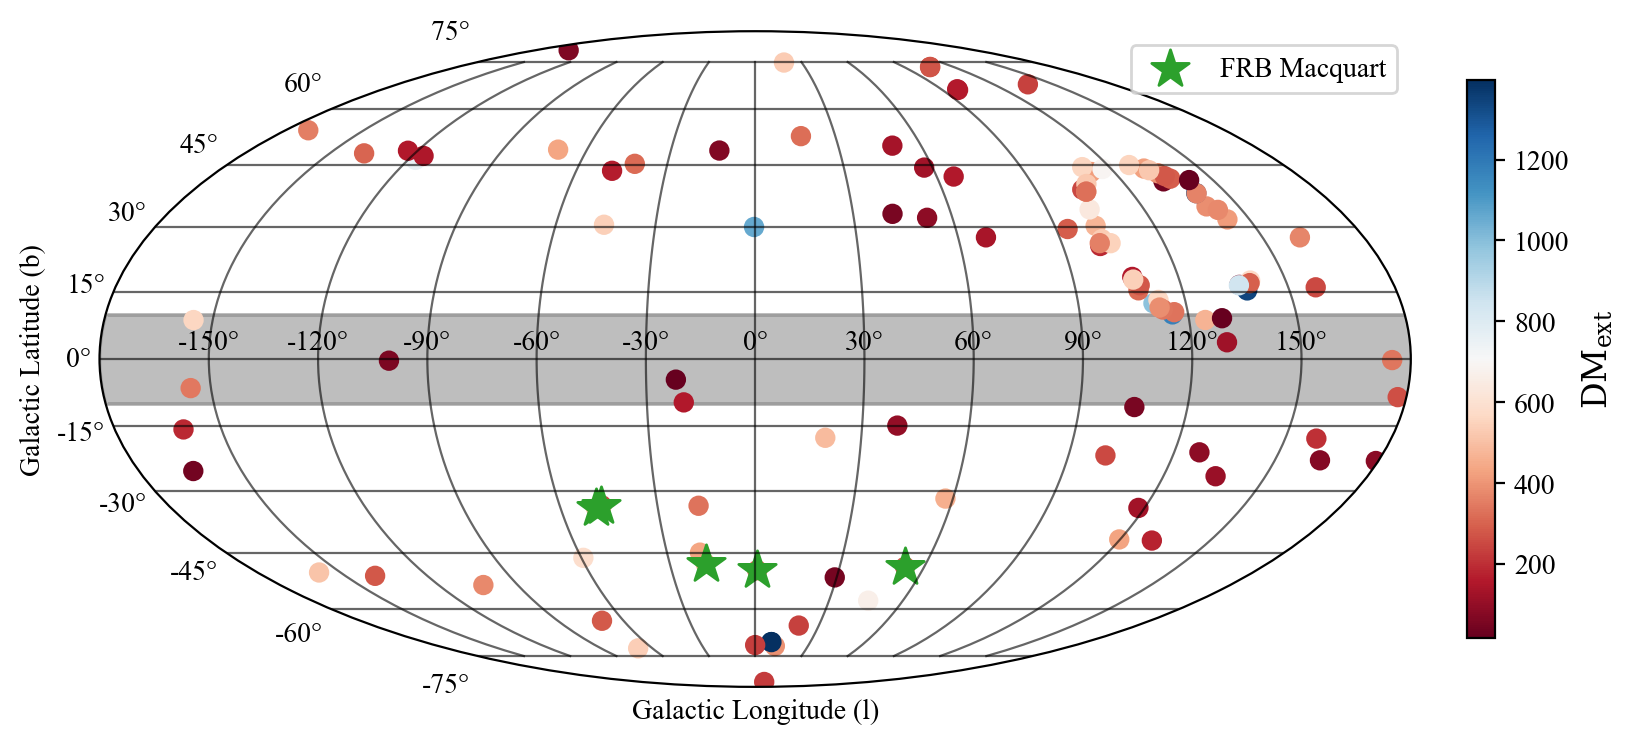

In [17]:
# Width of the Zone of Avoidance in degrees
b_max = 10  # ZoA from -10° to +10° in galactic latitude

# Galactic longitude from -180° to +180°
l_vals = np.linspace(-180, 180, 10)

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# # Concatenate to form a closed polygon (upper edge, reversed lower edge)
# l_full = np.concatenate([l_vals, l_vals[::-1]])
# b_full = np.concatenate([b_upper, b_lower[::-1]])

# Convert to radians
l_rad = np.deg2rad(l_vals)
b_rad_upper = np.deg2rad(b_upper)
b_rad_lower = np.deg2rad(b_lower)
gl_all_rad = np.deg2rad(gl_all)
gb_all_rad = np.deg2rad(gb_all)

# Plot in Mollweide projection
fig = plt.figure(figsize=(9, 5), dpi=200)
ax = fig.add_subplot(111, projection='mollweide')

# Fill the zone
ax.fill_between(l_rad, b_rad_lower, b_rad_upper, color='tab:gray', alpha=0.5)
map2 = ax.scatter(gl_all_rad, gb_all_rad, marker='o', s=40, c=frb_data_all['DM_ext'], cmap='RdBu')
ax.scatter(gl_macq_rad, gb_macq_rad, marker='*', s=200, c='tab:green', label='FRB Macquart')


# Format the plot
ax.grid(True, c='black', alpha=0.6)
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()


cbar = fig.colorbar(map2, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label(r'${\rm DM}_{\rm ext}$', fontsize=12)

if SAVE_FIG:
    plt.savefig("sky_all_gal.png", dpi=200)

plt.show()
plt.close()

3. Redshift cut data

In [18]:
gl_cut = Angle(frb_data_cut['gl']*u.deg).wrap_at(180 * u.deg).degree
gb_cut = frb_data_cut['gb']

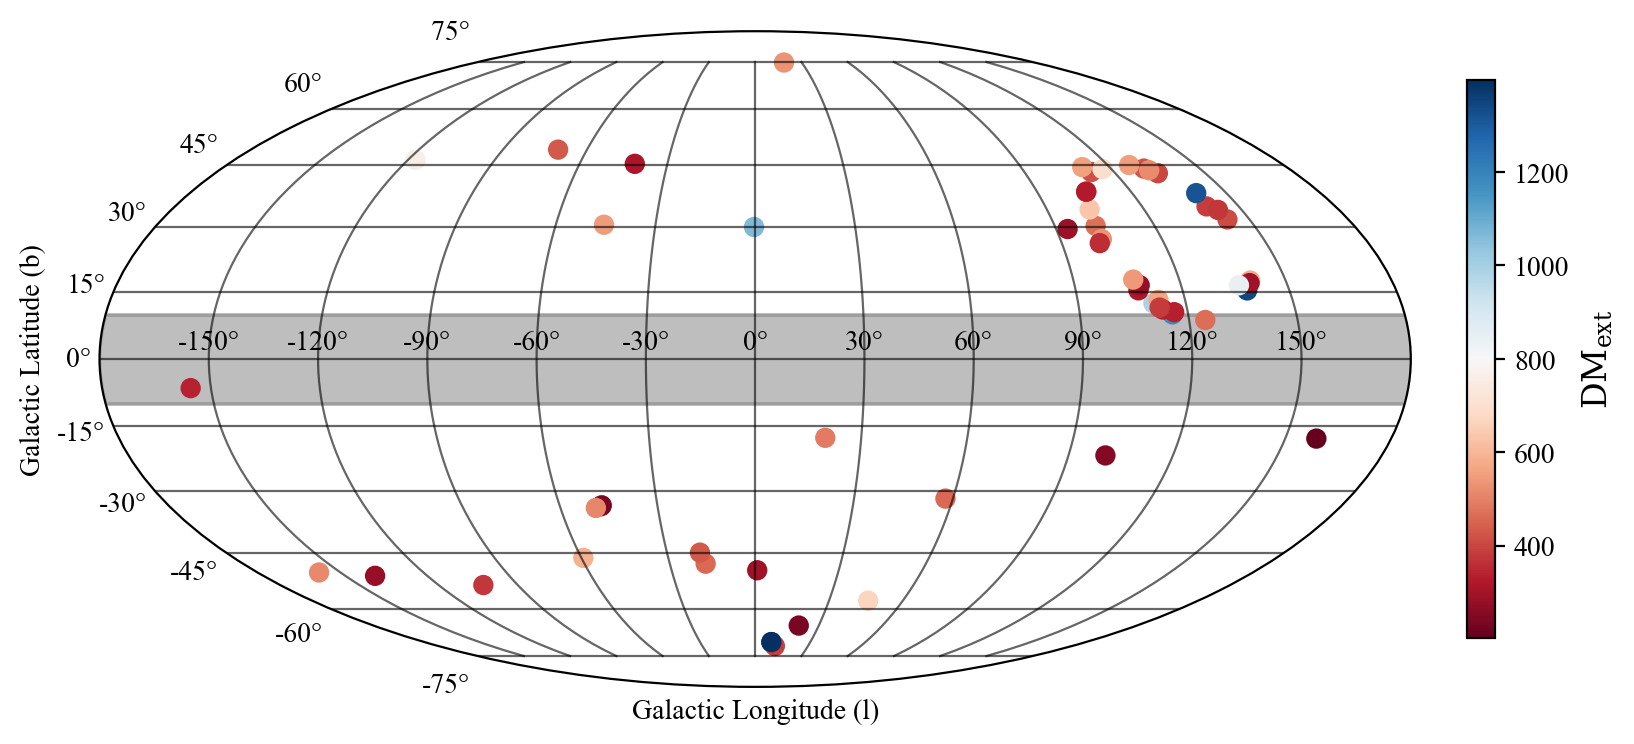

In [32]:
# Width of the Zone of Avoidance in degrees
b_max = 10  # ZoA from -10° to +10° in galactic latitude

# Galactic longitude from -180° to +180°
l_vals = np.linspace(-180, 180, 10)

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# # Concatenate to form a closed polygon (upper edge, reversed lower edge)
# l_full = np.concatenate([l_vals, l_vals[::-1]])
# b_full = np.concatenate([b_upper, b_lower[::-1]])

# Convert to radians
l_rad = np.deg2rad(l_vals)
b_rad_upper = np.deg2rad(b_upper)
b_rad_lower = np.deg2rad(b_lower)
gl_cut_rad = np.deg2rad(gl_cut)
gb_cut_rad = np.deg2rad(gb_cut)

# Plot in Mollweide projection
fig = plt.figure(figsize=(9, 5), dpi=200)
ax = fig.add_subplot(111, projection='mollweide')

# Fill the zone
ax.fill_between(l_rad, b_rad_lower, b_rad_upper, color='tab:gray', alpha=0.5)
map2 = ax.scatter(gl_cut_rad, gb_cut_rad, marker='o', s=40, c=frb_data_cut['DM_ext'], cmap='RdBu')
# ax.scatter(gl_macq_rad, gb_macq_rad, marker='*', s=200, c='tab:green', label='FRB Macquart')


# Format the plot
ax.grid(True, c='black', alpha=0.6)
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
# ax.legend()


cbar = fig.colorbar(map2, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label(r'${\rm DM}_{\rm ext}$', fontsize=12)

if SAVE_FIG:
    plt.savefig("sky_cut_gal.png", dpi=200)

plt.show()
plt.close()

- Histograms of $(l, b)$ coordinates

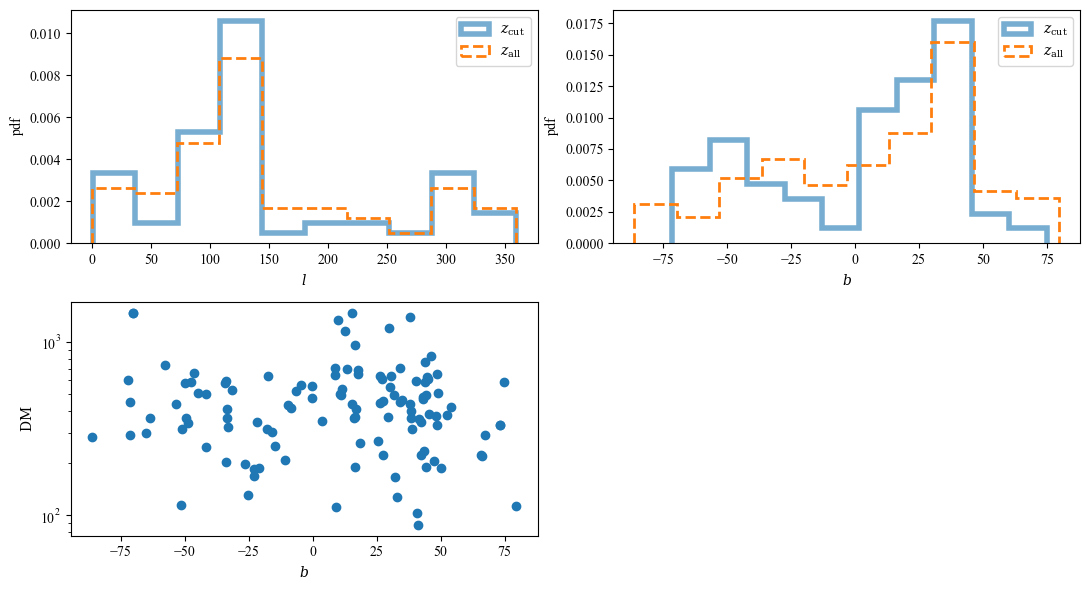

In [30]:
fig = plt.figure(figsize=(11, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.hist(frb_data_cut['gl'], histtype='step', density=True, label=r'$z_{\rm cut}$', lw=4, alpha=0.6)
ax1.hist(frb_data_all['gl'], histtype='step', density=True, label=r'$z_{\rm all}$', ls='--', lw=2)
ax1.set_xlabel(r'$l$')
ax1.set_ylabel(r'pdf')
ax1.legend()

ax2.hist(frb_data_cut['gb'], histtype='step', density=True, label=r'$z_{\rm cut}$', lw=4, alpha=0.6)
ax2.hist(frb_data_all['gb'], histtype='step', density=True, label=r'$z_{\rm all}$', ls='--', lw=2)
ax2.set_xlabel(r'$b$')
ax2.set_ylabel(r'pdf')
ax2.legend()

## Compare with Cordes & Chatterjee, 2019 (Fig. 4)
ax3.scatter(frb_data_all['gb'], frb_data_all['DM'])
ax3.set_xlabel(r'$b$')
ax3.set_ylabel(r'${\rm DM}$')
ax3.set_yscale('log')

plt.tight_layout()
plt.show()

---------------------------------

## Transform (RA, DEC) for a number of FRBs from CHIME2025 to (l,b)

Data from [[here](https://arxiv.org/pdf/2502.11217)].

In [11]:
RA_deg = np.array([151.66159, 106.96036, 238.73912, 91.10966, 184.62445, 54.66456, 269.12488, 246.02800, 18.24110, 346.75429, 270.78807, 82.62325, 199.57820, 54.58929, 207.99903, 112.44284, 259.54465, 26.46783, 72.79761])
DEC_deg = np.array([35.6941, 11.22452, 30.8987, 55.94595, 48.72993, 33.1593, 41.8143, 35.44871, 41.7491, 36.65268, 63.98908, 4.47554, 42.99271, 26.81767, 48.116, 56.25627, 29.49794, 35.11292, 2.39398])

In [13]:
coords_icrs = SkyCoord(ra=RA_deg*u.degree, dec=DEC_deg*u.degree, frame='icrs')

In [14]:
coords_galactic = coords_icrs.galactic

In [15]:
gb_chime_2025 = coords_galactic.b.deg
gl_chime_2025 = coords_galactic.l.deg

**Tip**: make `list()` for easier transfer to the `.csv` file

-----------------------------------------------------

## Sky projections

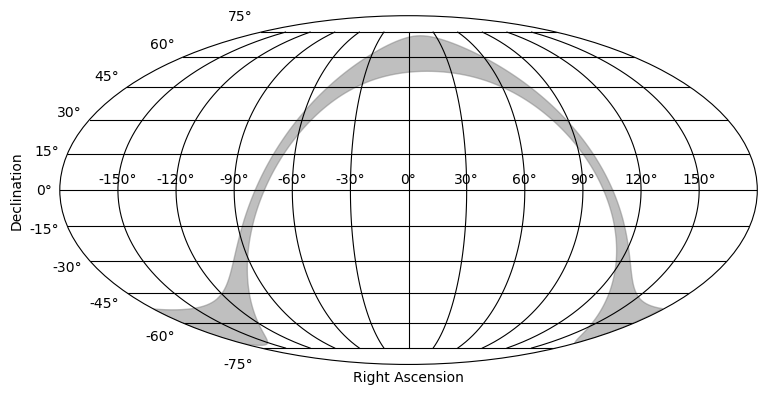

In [5]:
b_max = 10  # ZoA from -10° to +10° in galactic latitude

l_vals = np.linspace(-63, 296, 200)  # degrees

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# Convert to ICRS coordinates
gal_plane = SkyCoord(l=l_vals*u.deg, b=0*u.deg, frame='galactic')
gal_upper = SkyCoord(l=l_vals*u.deg, b=b_upper*u.deg, frame='galactic')
gal_lower = SkyCoord(l=l_vals*u.deg, b=b_lower*u.deg, frame='galactic')

icrs_plane = gal_plane.icrs
icrs_upper = gal_upper.icrs
icrs_lower = gal_lower.icrs

# Convert RA to [-180°, +180°] for Mollweide projection
ra_plane = icrs_plane.ra.wrap_at(180 * u.deg).radian
dec_upper = icrs_upper.dec.radian
dec_lower = icrs_lower.dec.radian

# Plot
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.fill_between(ra_plane, dec_lower, dec_upper, color='gray', alpha=0.5)

ax.grid(True, c='black')

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")

plt.show()

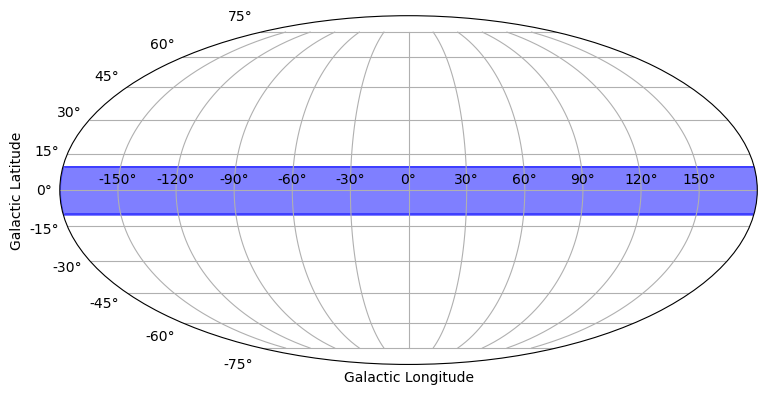

In [6]:
# Width of the Zone of Avoidance in degrees
b_max = 10  # ZoA from -10° to +10° in galactic latitude

# Galactic longitude from -180° to +180°
l_vals = np.linspace(-180, 180, 10)

# Define upper and lower bounds of ZoA
b_upper = np.repeat(b_max, len(l_vals))
b_lower = np.repeat(-b_max, len(l_vals))

# # Concatenate to form a closed polygon (upper edge, reversed lower edge)
# l_full = np.concatenate([l_vals, l_vals[::-1]])
# b_full = np.concatenate([b_upper, b_lower[::-1]])

# Convert to radians
l_rad = np.deg2rad(l_vals)
b_rad_upper = np.deg2rad(b_upper)
b_rad_lower = np.deg2rad(b_lower)

# Plot in Mollweide projection
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection='mollweide')

# Fill the zone
ax.fill_between(l_rad, b_rad_lower, b_rad_upper, color='blue', alpha=0.5)

# Format the plot
ax.grid(True)
ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")

plt.show()

--------------------------

Example to add coordinates

In [7]:
# Sample RA and DEC in degrees
ra = [10, 45, 80, 120, 200]    # Right Ascension
dec = [-10, 0, 20, 60, 85]     # Declination

In [8]:
coords = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

In [9]:
ra_rad = coords.ra.wrap_at(180*u.degree).radian
dec_rad = coords.dec.radian

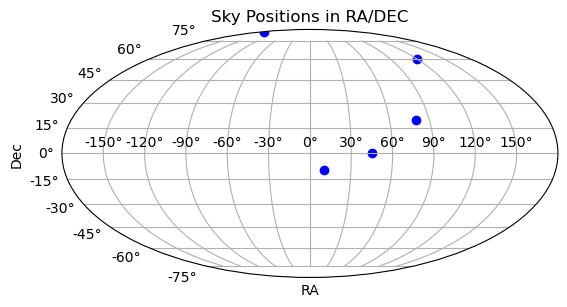

In [11]:
fig, ax = plt.subplots(subplot_kw={'projection': 'mollweide'})  # or use 'aitoff', etc.

ax.scatter(ra_rad, dec_rad, marker='o', color='blue')
ax.grid(True)

ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_title('Sky Positions in RA/DEC')
plt.show()